In [1]:
import tensorflow as tf
import os
import random
import numpy as np

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# verifica se tem alguma GPU disponivel

Num GPUs Available:  1


In [2]:
SEED = 123456# define uma seed especifica para nao complicar a execução do notebook e alcançar um resultado proximmo ao do instrutor
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# carrega os dados em partes como o treino e o teste

# verificando se se a quantidade dos dados realmente veio como esperado
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


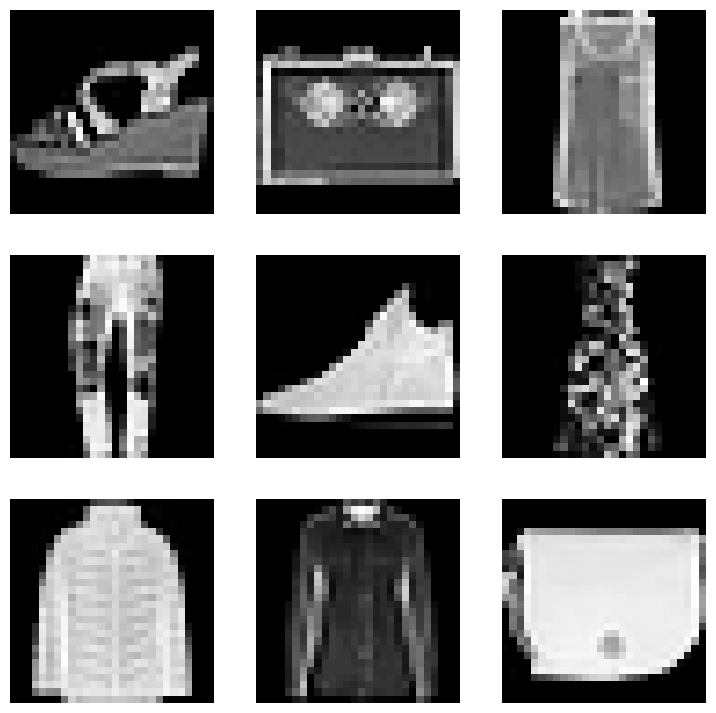

In [4]:
import numpy as np
from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))
# define a maior figura como 9x9

# escolhe dentre as 60 mil imagens, 9 para mostra-las
rndSamples = np.random.choice(60000, 9)

# para cada uma das 9 imagens escolhidas, plota a imagem 3x3
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[rndSamples[i]], cmap="Greys_r")
    # pega a imagem escolhida nos dados de treino
    plt.axis('off')

plt.show();

In [5]:
dataset = np.concatenate([x_train, x_test], axis=0)
# concatenamos o dataset pois como o intuito é gerar imagens com base no treino entao nao sera necessario a separação
dataset = np.expand_dims(dataset, -1).astype("float32") / 255
# normalização do canal de brilho e adicionado mais uma dimensao ao dataset para a entrada esperada do tensorflow

In [6]:
from tensorflow import keras
from tensorflow.keras import layers


class SamplingLayer(layers.Layer):
# a funcao call vai retornar o reparameterization trick, mostrado na aula aunterior
  def call(self, inputs):
    zMean, zLogVar = inputs
    # pega a media e o log de variancia vindos da tupla inputs
    batch = tf.shape(zMean)[0]
    # tamanho do lote é definido pela dimesao 0 de zMean
    dim = tf.shape(zMean)[1]# dimensionalidade latente
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return zMean + tf.exp(0.5 * zLogVar) * epsilon
    # converte o log para a variancia e desvio padrao, assim retornando o reparameterization trick

In [7]:
def buildEncoder(latentDim, encoderInputs):

  # modelo dequencial para o aprendizado das caracteristicas da imagem
  l1 = keras.models.Sequential([
    layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),# gera 128 feature maps
    layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),# 64 feature maps
    layers.Flatten(),# colocando em um vetor
    layers.Dense(256, activation="relu")# camada de densa
  ])

  x = l1(encoderInputs)#rodando para todos os dados

  # media em relação ao espaço latennte
  # metrica importante para a VAEs pois é calculado a distribuição das probabilidades
  zMean = layers.Dense(latentDim, name="z_mean")(x)

  # logvar, utilizado para a distribuição tambem
  zLogVar = layers.Dense(latentDim, name="z_log_var")(x)

  # aplicando a funncao que vai calcular o reparametization trick
  z = SamplingLayer()([zMean, zLogVar])

  # retorna o modelo keras com 3 saidas, a media, log variancia e a distribuicao
  return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")


# aciona o modelo keras para atender a um shappe de 28x28x1
encoderInputs = keras.Input(shape=(28, 28, 1))
# chamando a função
encoder = buildEncoder(2, encoderInputs)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256)       │    878,144 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer      │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 879,172 (3.35 MB)

 Trainable params: 879,172 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def buildDecoder(latentInputs):

  l1 = keras.models.Sequential([
    layers.Dense(7*7*64, activation="relu", input_shape=(latentInputs.shape[1],)),# exapndindo o vetor de duas dimensoes para 3136 valores
    layers.Reshape((7,7,64)),# transformando o tensor 1d para 3d, 7x7x64 canais
    layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),#invés de diminuir as imagens agora vamos aumentar, a cada Conv sera dobrado o seu tamanho, 7->14->28
    layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")# colocando em 1 canal, escala de cinza
    # sigmoid para garantir a entrada de normalização 0-1
  ])

  return keras.Model(latentInputs, l1(latentInputs), name="decoder")
  #adiciona ao modelo a mesma dimensao do espaco latente(2)

latentInputs = keras.Input(shape=(2,))
decoder = buildDecoder(latentInputs)# chamando o decoder
decoder.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       157,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,633 (615.75 KB)

 Trainable params: 157,633 (615.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def reconstructionLoss(data, reconstructed):
  #função de loss reconstruction penaliza o modelo ao ele nao criar uma immagem semelhante a original
  return tf.reduce_mean(
      tf.reduce_sum(
          keras.losses.binary_crossentropy(data, reconstructed),
          axis=(1, 2)
      )
  )

In [10]:
def klDivergenceLoss(zMean, zLogVar):
  # funcao KL calcula a distancia da distribuição das probabilidades, analisando a distancia entre a imagem original e a semelhante
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
          axis=1
      )
  )

In [11]:
def calcTotalLoss(data, reconstructed, zMean, zLogVar):
  # como não é possivel usar duas funcoes de perda, entao unimos as duas
  loss1 = reconstructionLoss(data, reconstructed)
  # aplica a funcao de reconstruction
  loss2 = klDivergenceLoss(zMean, zLogVar)
  # funcao kl
  klWeight = 3.0
  # peso para kl
  return  loss1, loss2, loss1 + klWeight * loss2
  # retorna as duas loss, e o total das duas somadas

In [12]:
class VAE(keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    # adiciona ao contrutor o encoder e decoder
    # tambem reastreadores das funcoes, que serao utilizados ao longo do treino
    self.totalLossTracker = keras.metrics.Mean(name="total_loss")
    # os losses somados
    self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
    # funcao de contruction
    self.klLossTracker = keras.metrics.Mean(name="kl_loss")
    # funcao kl

  # expoe as metricas
  @property
  def metrics(self):
    return [
        self.totalLossTracker,
        self.ceLossTracker,
        self.klLossTracker
    ]

  def train_step(self, data):
    # guarda no gradiente os pesos para se ajustar depois
    with tf.GradientTape() as tape:
        # forward path
        zMean, zLogVar, z = self.encoder(data)
        # pegando a media, logvariancia e a distribuição
        reconstruction = self.decoder(z)
        # com base na distribuicao o decoder reconstroi a imagem
        ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)
        # calculando as funcoes de perda com base no treino

    # pega os pesos do gradiente e a funcao total de loss
    grads = tape.gradient(totalLoss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
    # aplica as otimizações no modelo

    #atualizaa as funcoes para as que sairam do treino
    self.totalLossTracker.update_state(totalLoss)
    self.ceLossTracker.update_state(ceLoss)
    self.klLossTracker.update_state(klLoss)

    #retornando as funcoes de perda
    return {
        "total_loss": self.totalLossTracker.result(),
        "ce_loss": self.ceLossTracker.result(),
        "kl_loss": self.klLossTracker.result()
    }

In [13]:
vae = VAE(encoder, decoder)
#instanciando o modelo VAE
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
# compilando com o otimizador adam e learning rate
history = vae.fit(dataset, epochs=32, batch_size=128)
# treinando o modelo

Epoch 1/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - ce_loss: 299.6192 - kl_loss: 3.8667 - total_loss: 311.2192
Epoch 2/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 263.8868 - kl_loss: 4.7445 - total_loss: 278.1201
Epoch 3/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 260.9083 - kl_loss: 4.8472 - total_loss: 275.4498
Epoch 4/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 259.3456 - kl_loss: 4.9011 - total_loss: 274.0491
Epoch 5/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 258.1925 - kl_loss: 4.9403 - total_loss: 273.0137
Epoch 6/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - ce_loss: 257.1851 - kl_loss: 4.9836 - total_loss: 272.1359
Epoch 7/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 256.4164 - kl_loss: 5.0275 - total_loss: 271.4990
Epoch 8/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 255.6722 - kl_loss: 5.0477 - total_loss: 270.8151
Epoch 9/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - ce_loss: 255.3535 - kl_loss: 5.

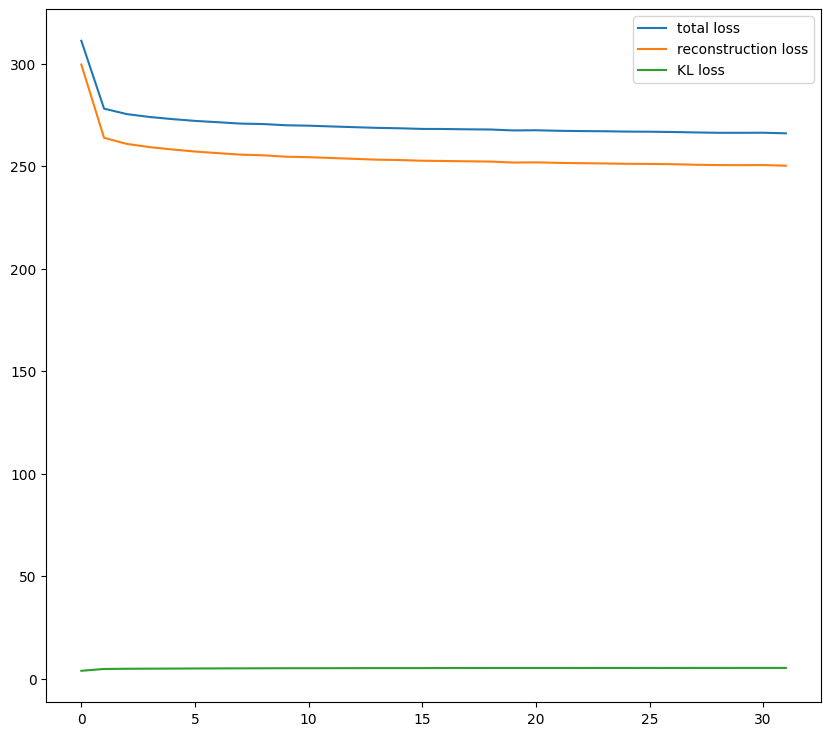

In [14]:
plt.figure(figsize=(10, 9))
# historico das funcoes de perda ao longo do treino
plt.plot(history.history.get('total_loss'), label="total loss")
plt.plot(history.history.get('ce_loss'), label="reconstruction loss")
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

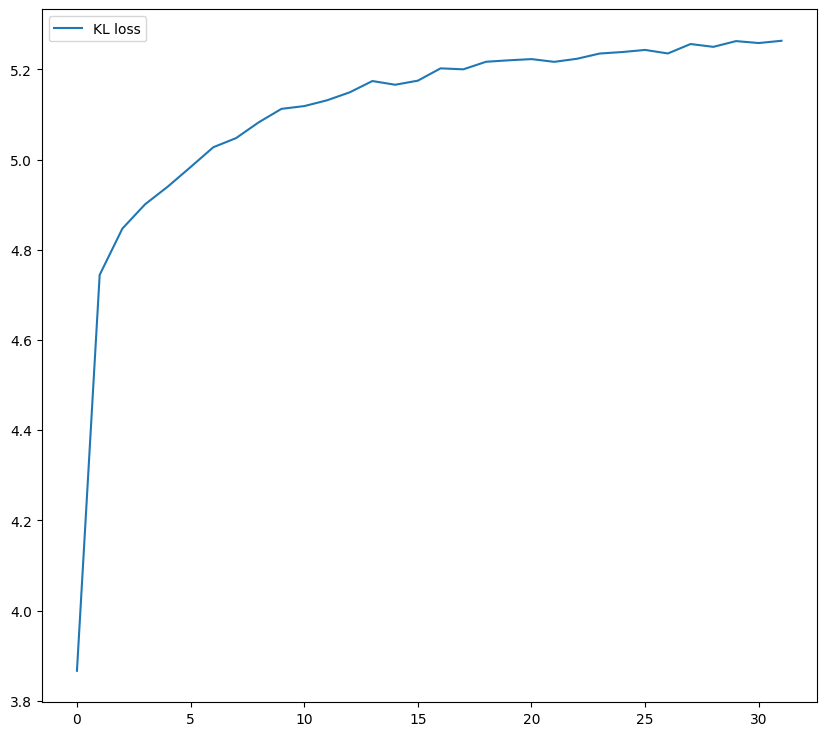

In [15]:
plt.figure(figsize=(10, 9))
# funcao de kl
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step


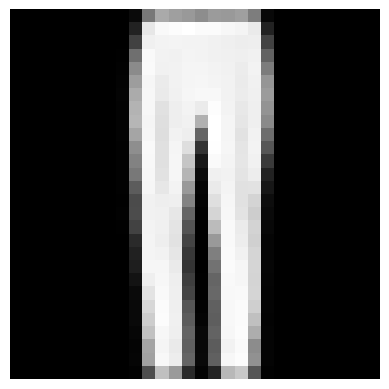

In [17]:
synth = vae.decoder.predict(np.array([[1, 2]]))
# gerando uma imagem a partir do decoder com a media 1 e variancia 2, tendo eles na distribuição de probabilidades
plt.axis('off')
plt.imshow(synth.reshape((28,28)), cmap="Greys_r");
# imagem 28x28 em escala de cinza

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step  


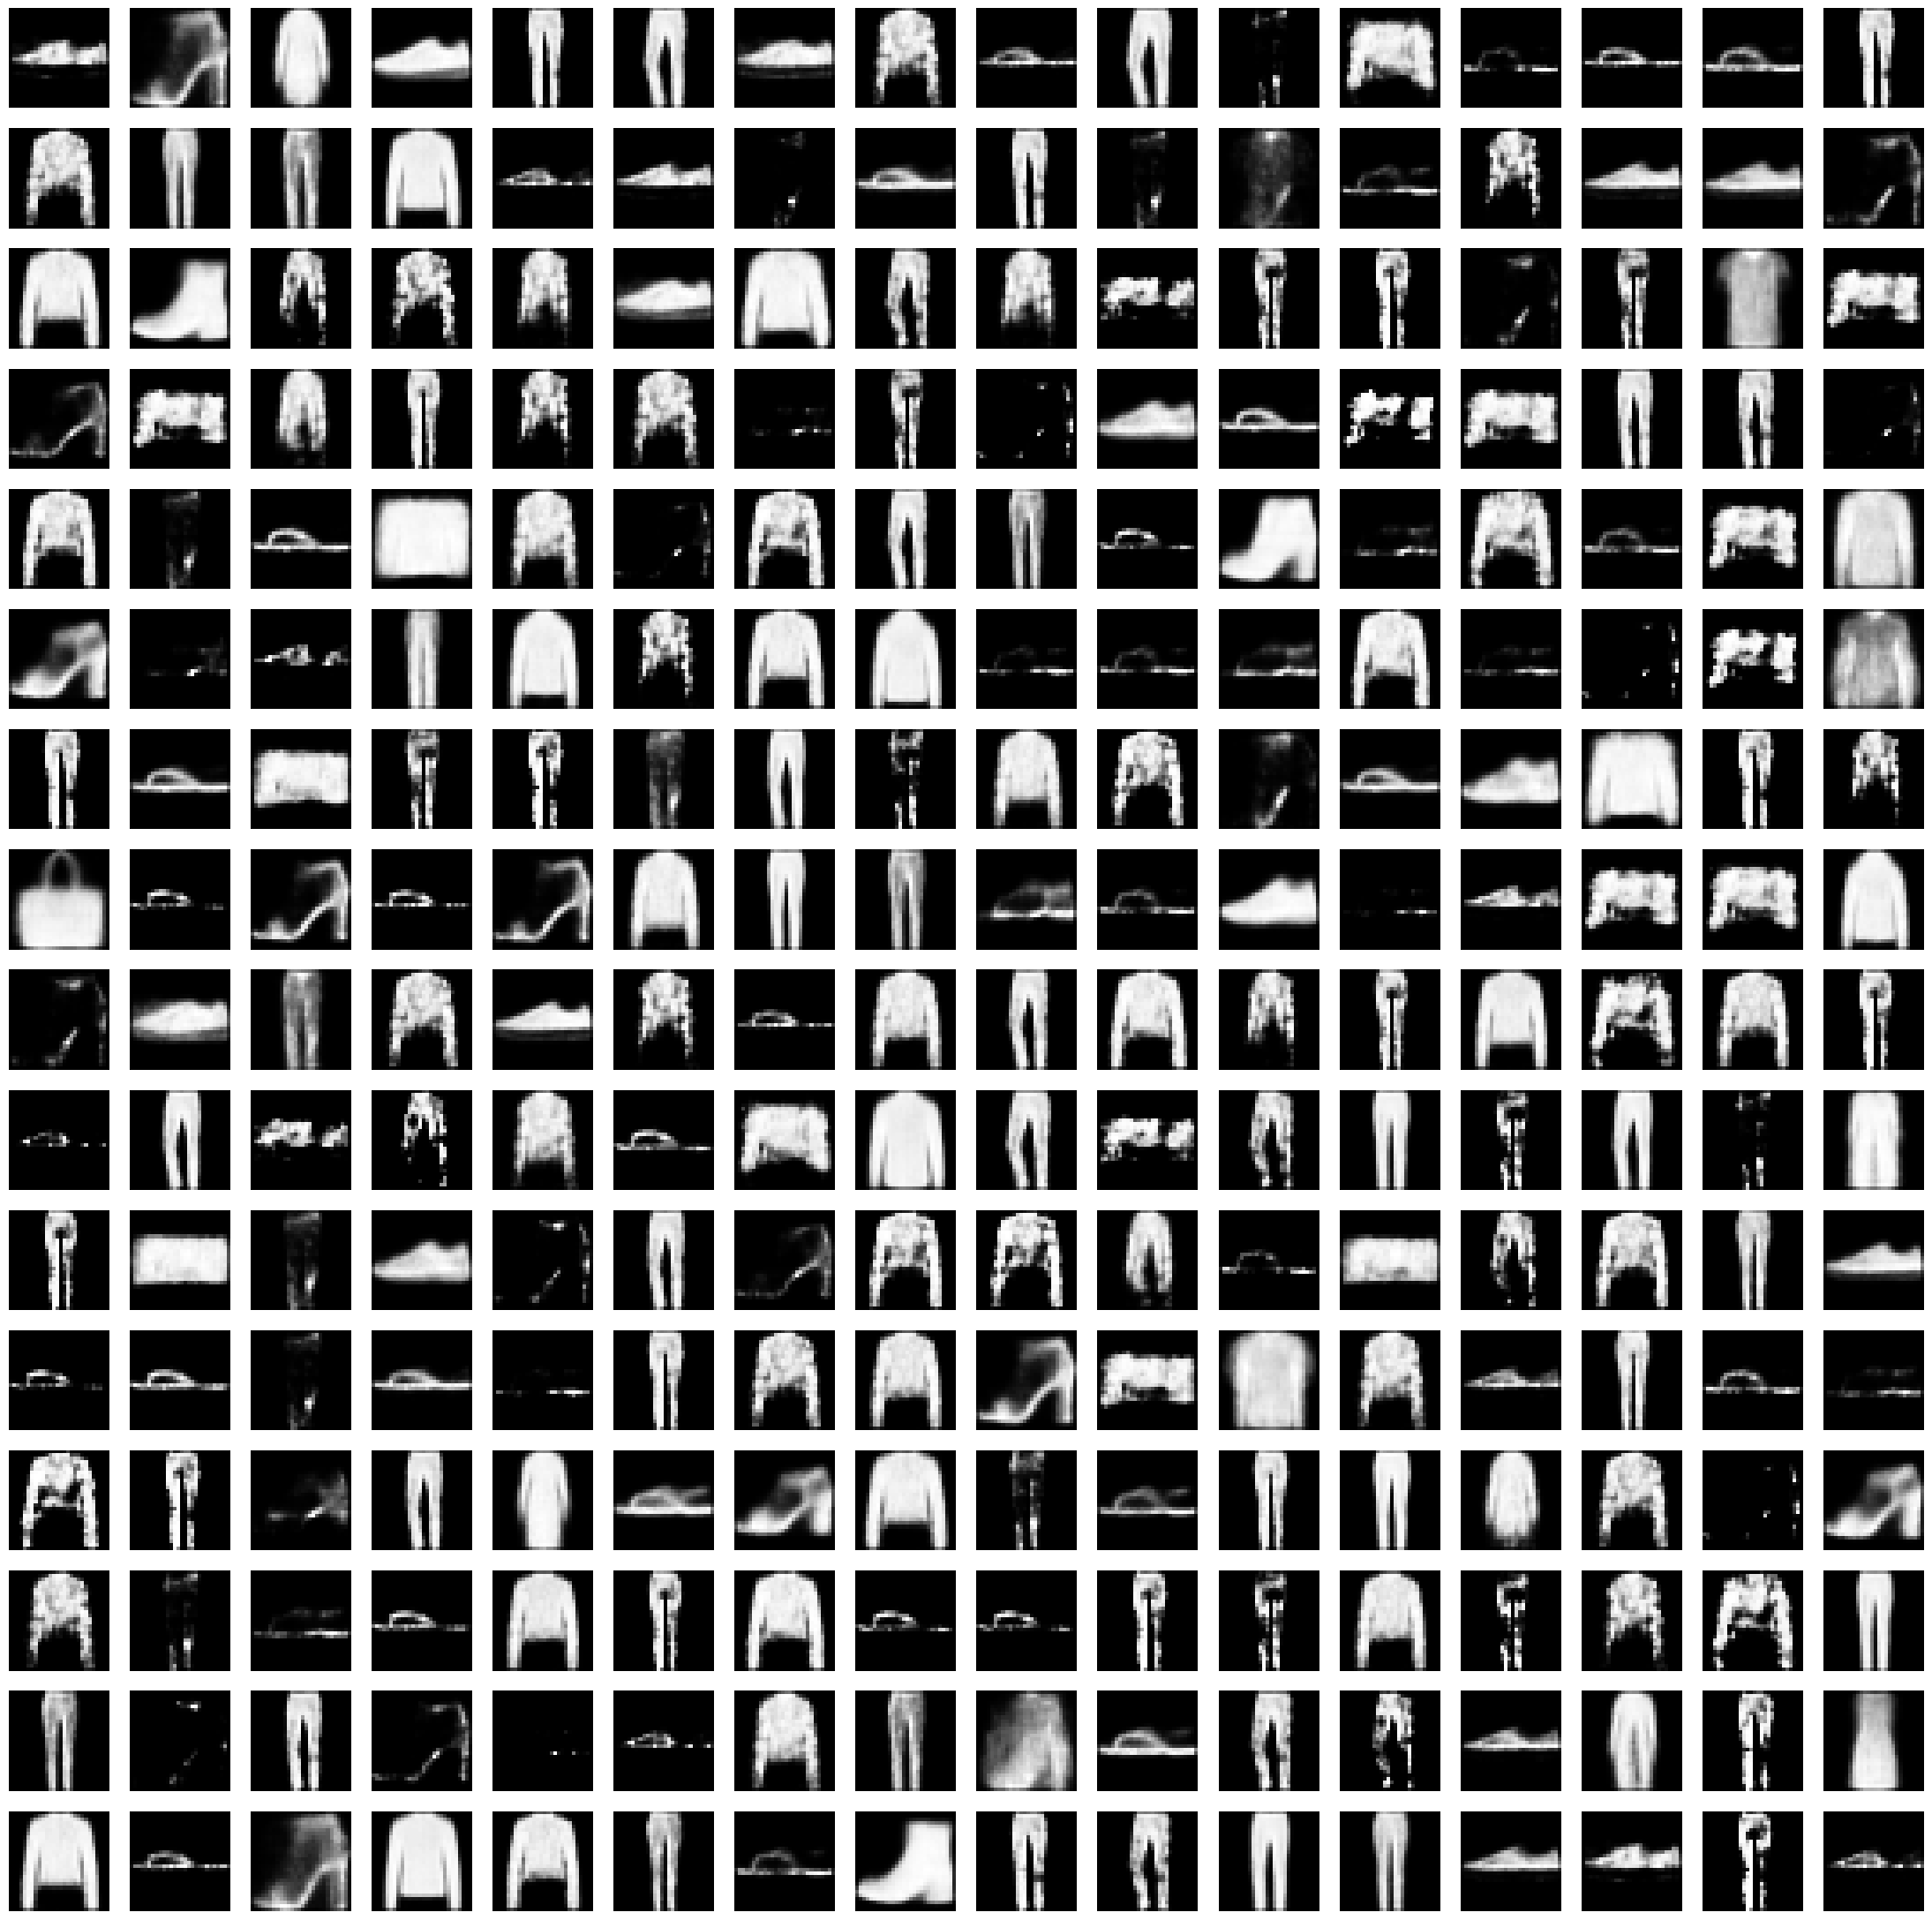

In [18]:
z = np.random.normal(loc=0, scale=4, size=(256,2))
# um adistribuiçaõ para 256 imagens
synth = vae.decoder.predict(z)
# previsao e gerando iamgens a partir da distribuição

plt.figure(figsize=(28,28))

for i in range(256):
    plt.subplot(16,16,i+1)
    plt.imshow(synth[i].reshape((28,28)), cmap="Greys_r")
    plt.axis('off')
    # mostrando cada imagem gerada

plt.show();

In [19]:
idx = 1280
batch = np.expand_dims(x_train[idx], axis=0)
#pega a imagem dos dados de treino
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255
# adiciona mais uma dimensao e a normaliza para o intervalo de 0-1
print(batchOfImages.shape)
_, _, z = vae.encoder.predict(batchOfImages)
# aplicando o encoder a imagem

# para o expaço latente usa o decoder para reconstrui-la
synth = vae.decoder.predict([z])

z

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=('Tensor(shape=(1, 2))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


array([[0.69709015, 0.9981746 ]], dtype=float32)

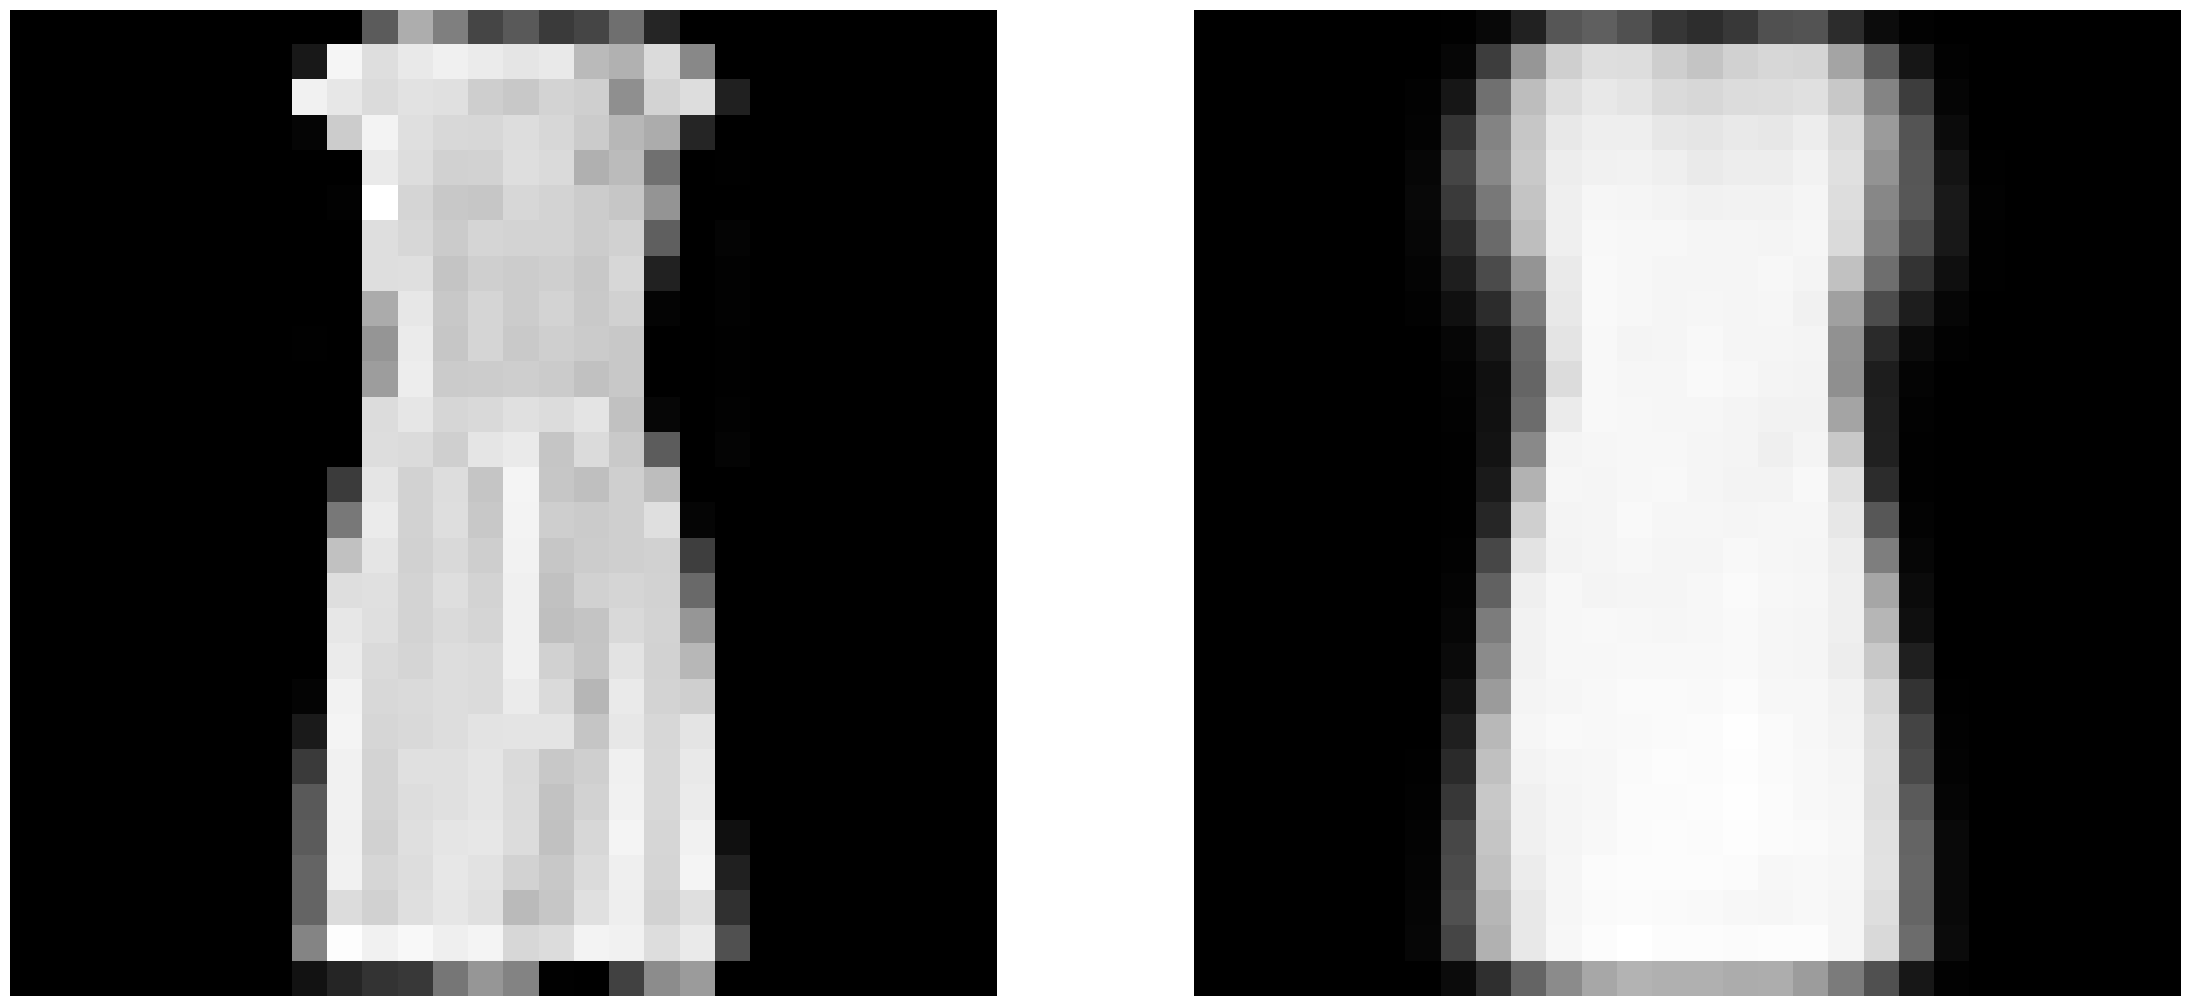

In [20]:
plt.figure(figsize=(28, 28))

# comparação de imagem original com a reconstruida
plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(x_train[idx], cmap="Greys_r")

plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(synth[0].reshape((28,28)), cmap="Greys_r")
plt.show();

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


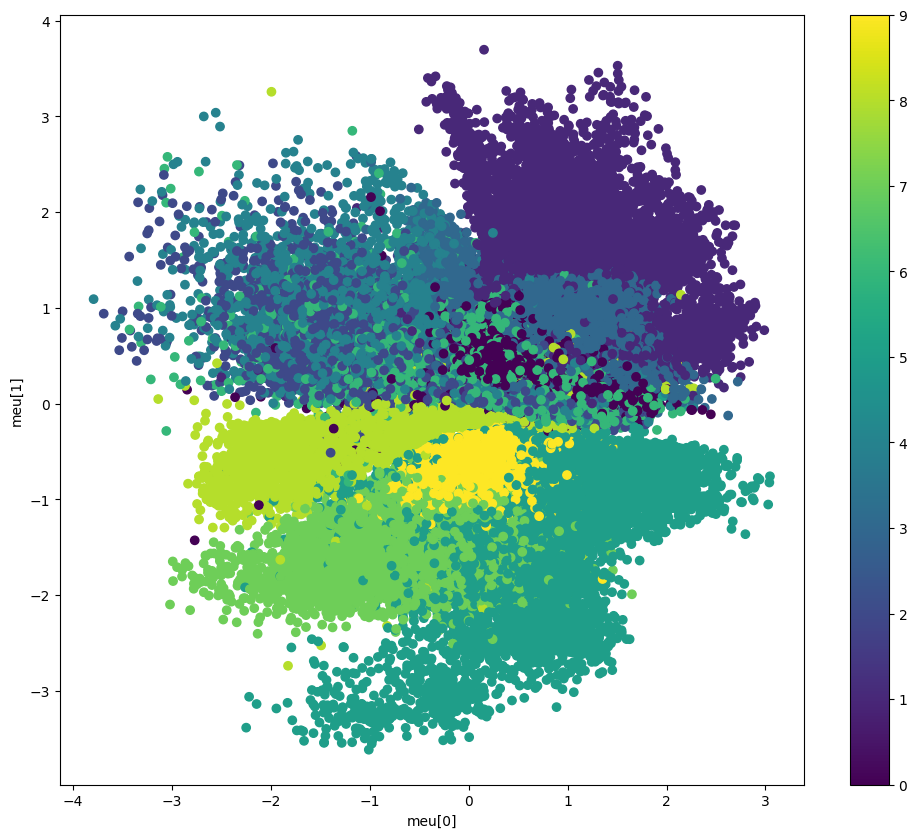

In [21]:
#vendo o grafico de distribuição dos dados de teste, ao apllicar o encoder aos dados de teste
labels = np.concatenate([y_train, y_test], axis=0)
meu, _, _ = vae.encoder.predict(dataset)
plt.figure(figsize=(12, 10))
plt.scatter(meu[:, 0], meu[:, 1], c=labels)
plt.colorbar()
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.show();